In [1]:
# ==========================================
# Maximum Diversification Portfolio
# ==========================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

# ==========================================
# Portfolio Assets
# ==========================================

assets = [
    "GOLDBEES.NS",
    "HDFCBANK.NS",
    "RELIANCE.NS",
    "TCS.NS"
]

benchmark = "^NSEI"

# ==========================================
# Download Historical Prices
# ==========================================

prices = yf.download(
    assets + [benchmark],
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)["Close"]

# ==========================================
# Portfolio & Benchmark Prices
# ==========================================

portfolio_prices = prices[assets]
benchmark_prices = prices[benchmark]

# ==========================================
# Daily Returns
# ==========================================

returns = portfolio_prices.pct_change(fill_method=None).dropna()
benchmark_returns = benchmark_prices.pct_change(fill_method=None).dropna()

# ==========================================
# Annualized Volatility
# ==========================================

volatility = returns.std() * np.sqrt(252)

# ==========================================
# Annualized Covariance Matrix
# ==========================================

cov_matrix = returns.cov() * 252

# ==========================================
# Diversification Ratio Function
# ==========================================

def diversification_ratio(weights, vol, cov):

    weighted_vol = np.dot(weights, vol)
    portfolio_vol = np.sqrt(weights.T @ cov @ weights)

    return -(weighted_vol / portfolio_vol)

# ==========================================
# Optimization Setup
# ==========================================

n_assets = len(assets)

initial_weights = np.repeat(1/n_assets, n_assets)

constraints = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

bounds = tuple((0,1) for _ in range(n_assets))

# ==========================================
# Optimize
# ==========================================

result = minimize(
    diversification_ratio,
    initial_weights,
    args=(volatility.values, cov_matrix.values),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

# ==========================================
# Portfolio Weights
# ==========================================

weights = pd.Series(result.x, index=assets)

print("\nMaximum Diversification Portfolio Weights")
print(weights)

[*********************100%***********************]  5 of 5 completed



Maximum Diversification Portfolio Weights
GOLDBEES.NS    0.527566
HDFCBANK.NS    0.182848
RELIANCE.NS    0.117504
TCS.NS         0.172083
dtype: float64


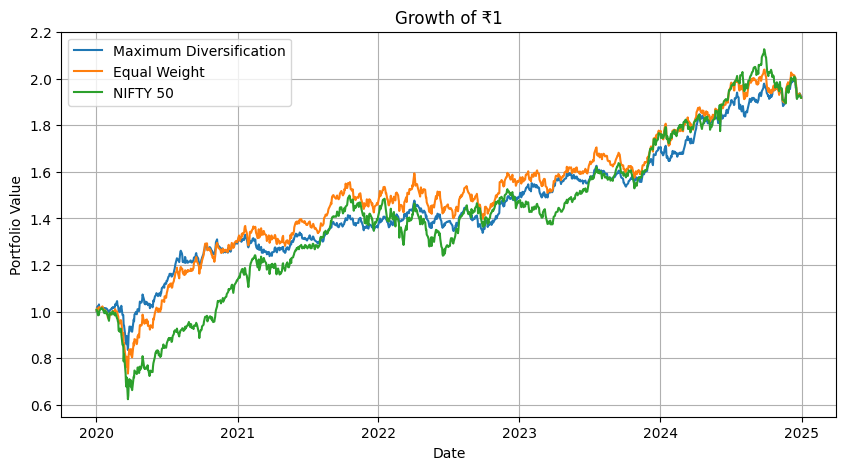

In [3]:
# ==========================================
# Align Return Series
# ==========================================

combined_returns = pd.concat(
    [portfolio_returns, equal_returns, benchmark_returns],
    axis=1,
    join="inner"
)

combined_returns.columns = [
    "Maximum Diversification",
    "Equal Weight",
    "NIFTY 50"
]

portfolio_returns = combined_returns["Maximum Diversification"]
equal_returns = combined_returns["Equal Weight"]
benchmark_returns = combined_returns["NIFTY 50"]

# ==========================================
# Growth of ₹1
# ==========================================

portfolio_growth = (1 + portfolio_returns).cumprod()
equal_growth = (1 + equal_returns).cumprod()
benchmark_growth = (1 + benchmark_returns).cumprod()

# ==========================================
# Plot Growth Comparison
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(portfolio_growth, label="Maximum Diversification")
plt.plot(equal_growth, label="Equal Weight")
plt.plot(benchmark_growth, label="NIFTY 50")

plt.title("Growth of ₹1")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
# ==========================================
# Performance Metrics Function
# ==========================================

def performance_metrics(r):

    # CAGR
    cagr = (1 + r).prod()**(252/len(r)) - 1

    # Annualized Volatility
    annual_vol = r.std() * np.sqrt(252)

    # Sharpe Ratio (Risk-free rate = 0)
    sharpe = cagr / annual_vol

    # Sortino Ratio
    downside = r[r < 0].std() * np.sqrt(252)
    sortino = cagr / downside

    # Maximum Drawdown
    cumulative = (1 + r).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    # Calmar Ratio
    calmar = cagr / abs(max_drawdown)

    # VaR (95%)
    var95 = np.percentile(r, 5)

    # CVaR (95%)
    cvar95 = r[r <= var95].mean()

    return pd.Series({
        "CAGR": cagr,
        "Annual Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_drawdown,
        "Calmar Ratio": calmar,
        "VaR (95%)": var95,
        "CVaR (95%)": cvar95
    })

# ==========================================
# Performance Comparison
# ==========================================

comparison = pd.DataFrame({
    "Maximum Diversification": performance_metrics(portfolio_returns),
    "Equal Weight": performance_metrics(equal_returns),
    "NIFTY 50": performance_metrics(benchmark_returns)
})

print("\nPerformance Comparison")
print(comparison)


Performance Comparison
                   Maximum Diversification  Equal Weight  NIFTY 50
CAGR                              0.142788      0.142115  0.142083
Annual Volatility                 0.123377      0.161367  0.191158
Sharpe Ratio                      1.157324      0.880693  0.743277
Sortino Ratio                     1.552877      1.146932  0.837806
Max Drawdown                     -0.200473     -0.281658 -0.384399
Calmar Ratio                      0.712253      0.504566  0.369624
VaR (95%)                        -0.010599     -0.013901 -0.016315
CVaR (95%)                       -0.016919     -0.022578 -0.029456
